In [1]:
import ipywidgets as widgets
import sys
import fastcore
import torch
from fastai.vision.all import *
from fastai.vision.widgets import *
import fastbook
from fastai.callback.tracker import SaveModelCallback
import gc

## For clearing VRAM

In [12]:
del learn
gc.collect()
torch.cuda.empty_cache()

## Initial Model Training

In [13]:
path = Path('/home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/triage_training_data')
def label_func(path):
    return path.parent.name

In [15]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=label_func,
    item_tfms=Resize(384),
    batch_tfms=RandomResizedCrop(384)
)

dls = dblock.dataloaders(path, bs=32)

In [ ]:
learn = vision_learner(dls, convnext_tiny, metrics=accuracy)
learn.to_fp16()
learn.fine_tune(epochs=10, cbs=[SaveModelCallback(every_epoch=True, fname='tiny_triage')])

In [17]:
learn_pretrained = vision_learner(dls, convnext_tiny, pretrained=False, metrics=[accuracy, error_rate])
learn_pretrained.load('tiny_triage_90percent')
learn_pretrained.to_fp16()
learn_pretrained.fine_tune(epochs=10, cbs=[SaveModelCallback(every_epoch=True, fname='tiny_triage')])

/home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/.venv/lib/python3.11/site-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.315537,0.113793,0.950450,0.049550,00:10


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.318367,0.091950,0.972973,0.027027,00:12
1,0.298798,0.092963,0.963964,0.036036,00:12
2,0.261134,0.127703,0.941441,0.058559,00:12
3,0.233536,0.097576,0.959459,0.040541,00:12
4,0.206920,0.119540,0.945946,0.054054,00:12
5,0.208511,0.112681,0.954955,0.045045,00:12
6,0.183446,0.125884,0.954955,0.045045,00:12
7,0.164598,0.122366,0.941441,0.058559,00:12
8,0.142296,0.120873,0.945946,0.054054,00:12
9,0.128227,0.120383,0.954955,0.045045,00:12


## Data cleaning

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(20, nrows=20)

In [10]:
cleaner = ImageClassifierCleaner(learn)
cleaner

In [11]:
review_path = Path('/home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/triage_training_data/review')
for idx in cleaner.delete(): cleaner.fns[idx].unlink()
for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)

## Add Outlier Detection

In the following section we are going to use an energy out-of-distribution method to detect outlier photos. Outlier photos are those that the model is lacking confidence in. These photos will be flagged for manual review.

In [31]:
import torch
import shutil
from fastai.vision.all import *

# --- 1. SETTINGS & PATHS ---
weights_path = Path('/home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/DataPipeline/triage_model/models/triage_model') # Path to your .pth (don't include .pth)
data_100k_root = Path('/home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data')
clean_out = Path('Cleaned_Production_Data')
review_out = Path('Gemini_Review_Required')
triage_vocab = ['unusable', 'usable']

# Calibrate this! Start at 1.8; higher = more trusting, lower = more skeptical
ENERGY_THRESHOLD = 1.8 

# --- 2. RECONSTRUCT THE SHELL & LOAD WEIGHTS ---
# We need a dummy DLS just to initialize the learner shell
# Use one folder from your set just to get the class count right (2 classes)
dls = ImageDataLoaders.from_folder(data_100k_root, valid_pct=0.2, item_tfms=Resize(224))
learn = vision_learner(dls, convnext_tiny, metrics=accuracy, n_out=2)
learn.dls.vocab = triage_vocab

# Load the weights from your .pth file
learn.load(weights_path)
learn.model.eval() # Set to evaluation mode

# --- 3. RECURSIVE FILE COLLECTION ---
# This grabs all images from all 100 species subfolders
print(f"Scanning {data_100k_root}...")
all_files = get_image_files(data_100k_root, recurse=True)
test_dl = learn.dls.test_dl(all_files)

# --- 4. THE ENERGY SWEEP ---
print(f"Running triage on {len(all_files)} images...")
with torch.no_grad():
    # act=None is vital: we need raw logits, not squashed softmax probabilities
    logits, _ = learn.get_preds(dl=test_dl, act=None, with_input=False)

    # Energy Calculation: E(x) = -logsumexp(logits)
    # Higher energy = "I've never seen anything like this before" (OOD)
    energies = -torch.logsumexp(logits, dim=1)
    preds = logits.argmax(dim=1) # 0: Unusable, 1: Usable


Scanning /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data...
Running triage on 100315 images...


In [32]:
import pandas as pd

# 1. Run inference
with torch.no_grad():
    logits, _ = learn.get_preds(dl=test_dl, act=None)
    energies = -torch.logsumexp(logits, dim=1).cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()

# 2. Map the 0/1 back to 'unusable'/'usable'
predictions = [triage_vocab[p] for p in preds]

# 3. Build the Audit Manifest
audit_df = pd.DataFrame({
    'filename': [f.name for f in all_files],
    'original_species': [f.parent.name for f in all_files], # Tells you which subfolder it was in
    'triage_decision': predictions,
    'energy': energies,
    'full_path': [str(f) for f in all_files]
})

# 4. View a sample of 'Unusable' predictions to see if they're actually junk
print(audit_df[audit_df['triage_decision'] == 'unusable'].head(10))

   filename   original_species triage_decision    energy  \
1   950.jpg  Jacobaea vulgaris        unusable -1.288675   
8   210.jpg  Jacobaea vulgaris        unusable -1.240325   
15  480.jpg  Jacobaea vulgaris        unusable -1.312273   
21  600.jpg  Jacobaea vulgaris        unusable -1.313178   
24  444.jpg  Jacobaea vulgaris        unusable -1.312955   
25  838.jpg  Jacobaea vulgaris        unusable -1.193301   
33  988.jpg  Jacobaea vulgaris        unusable -1.206128   
37  258.jpg  Jacobaea vulgaris        unusable -1.256481   
38  151.jpg  Jacobaea vulgaris        unusable -1.196712   
39  815.jpg  Jacobaea vulgaris        unusable -1.287488   

                                                                                                          full_path  
1   /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data/Jacobaea vulgaris/950.jpg  
8   /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data/Jacobaea vulg

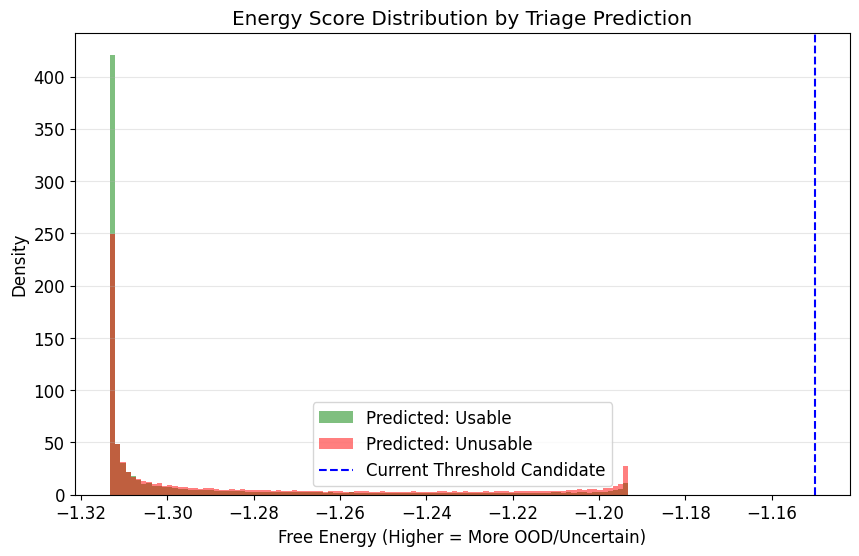

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Convert tensors to numpy for plotting
e_np = energies
p_np = preds

# 2. Separate energy scores by predicted class
# Assuming Index 1 is 'usable' and Index 0 is 'unusable'
usable_energies = e_np[p_np == 1]
unusable_energies = e_np[p_np == 0]

# 3. Plotting the Distributions
plt.figure(figsize=(10, 6))
plt.hist(usable_energies, bins=100, alpha=0.5, label='Predicted: Usable', color='green', density=True)
plt.hist(unusable_energies, bins=100, alpha=0.5, label='Predicted: Unusable', color='red', density=True)

plt.axvline(x=-1.15, color='blue', linestyle='--', label='Current Threshold Candidate') # Visual guide

plt.title('Energy Score Distribution by Triage Prediction')
plt.xlabel('Free Energy (Higher = More OOD/Uncertain)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('energy_distribution.png')

In [35]:
import numpy as np

# Assuming Index 1 is Usable and 0 is Unusable
usable_idx = (preds == 1)
usable_energies = energies[usable_idx]

# Find the 95th and 99th percentiles of the 'Usable' group
# Note: Since your energies are negative, the 'highest' energy 
# is the least negative (closer to zero).
p95 = np.percentile(usable_energies, 95)
p99 = np.percentile(usable_energies, 99)

print(f"95% of Usable photos are below: {p95:.4f}")
print(f"99% of Usable photos are below: {p99:.4f}")
print(f"Max energy found: {usable_energies.max():.4f}")

95% of Usable photos are below: -1.2064
99% of Usable photos are below: -1.1938
Max energy found: -1.1931


In [36]:
class_names = [learn.dls.vocab[p] for p in preds]

df = pd.DataFrame({
    'file': [f.name for f in all_files],
    'path': [str(f) for f in all_files],
    'prediction': class_names,
    'energy': energies
})

# 3. Export for your review
df.to_csv('triage_audit.csv', index=False)

In [29]:
# Get indices of photos in the top 1% of energy (the least certain 'Usable' ones)
sketchy_indices = np.where((preds == 1) & (energies >= p99))[0]

# Sample 10 random files from this 'sketchy' group
sample_files = [all_files[i] for i in np.random.choice(sketchy_indices, 10)]

for f in sample_files:
    print(f"Audit this: {f}")

Audit this: /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data/Mycelis muralis/895.jpg
Audit this: /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data/Daucus carota/492.jpg
Audit this: /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data/Petasites frigidus/339.jpg
Audit this: /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data/Heracleum maximum/30.jpg
Audit this: /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data/Cirsium arvense/319.jpg
Audit this: /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data/Rubus armeniacus/464.jpg
Audit this: /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data/Ranunculus repens/325.jpg
Audit this: /home/ctristan/Documents/devlearning/PythonProjects/FieldGuidePrototype/training_data/Ilex aquifolium/673.jpg
Audit this: /home/c

In [ ]:
# --- 5. RECURSIVE SORTING & METADATA PRESERVATION ---
print("Sorting files into production and review bins...")
for i, file_path in enumerate(all_files):
    species_name = file_path.parent.name
    energy_val = energies[i].item()
    pred_idx = preds[i].item()
    
    # Determine the destination
    if pred_idx == 1 and energy_val < ENERGY_THRESHOLD:
        # Pass: High confidence usable
        dest_dir = clean_out / species_name
    elif energy_val >= ENERGY_THRESHOLD:
        # Flag: Model is confused, ask Gemini
        dest_dir = review_out / species_name
    else:
        # Fail: Model says unusable and isn't confused about it
        continue 

    # Create the species subfolder in the new location and copy
    dest_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy2(file_path, dest_dir / file_path.name)

print(f"Sweep complete. Check {clean_out} for your production set.")